# Running ICON from Python

This notebook is a small, inspectable ICON experiment. It uses a global ICON grid, builds the dry Jablonowski-Williamson `JW26` analytical initial state, advances that state with the ICON4Py dynamical core and diffusion, and plots the result directly from the current in-memory xarray fields.

The goal is not to hide ICON4Py behind a polished application. The goal is to show the main objects a model run needs:

- `config`: plain Python settings for the experiment.
- `grid`: horizontal/vertical grid information and ICON connectivity data.
- `state`: prognostic fields such as density, virtual potential temperature, Exner pressure, and wind.
- `model`: the initialized dycore/diffusion time-integration object.

The helper implementation lives in `icon4py_helper.py`; this notebook keeps the visible workflow focused on the model objects and the order in which they are used.

In [1]:
from icon4py_helper import (
    check_config,
    create_grid,
    create_state,
    init_state,
    create_model,
    plot_field,
    plot_diagnostics,
)

## Background

The workflow uses a deliberately small API. Each call has one job:

| Call | What it does | Main output or side effect |
| --- | --- | --- |
| `check_config(config)` | Merges your config dictionary with defaults and validates values before expensive setup begins. | Returns a normalized config dictionary. |
| `create_grid(config)` | Resolves the requested ICON grid, builds ICON connectivity/geometry data, selects the backend allocator, and computes the vertical level distribution. | Returns `grid`, a dictionary-like object with plotting coordinates, dimensions, and vertical levels. |
| `create_state(grid, config, tracers=None)` | Creates an initially empty state container that is tied to the grid/backend. | Returns `state`, a mutable run object. Its public fields become xarray objects after initialization. |
| `init_state(grid, state, "JW26", config)` | Builds the ICON4Py JW experiment config, prepares static grid support fields, allocates prognostic fields, and fills the analytical initial condition. | Mutates `state` in place and exposes the latest instant as `state["xarray"]`. |
| `plot_field(grid, field, ..., projection="flat")` | Draws one cell-centered xarray field or expression on the ICON triangular grid. If `field` is `None`, it draws only gridlines. | Displays one flat plot or one rotatable sphere. |
| `create_model(grid, state, config)` | Initializes the ICON4Py dycore/diffusion granules and assembles the time-step state. | Returns `model`. No separate explicit compile phase is required. |
| `model.step(grid, state, count=n, diagnostics=diagnostics)` | Advances the dycore/diffusion model by `n` additional timesteps from the current state. | Mutates `state`; if a diagnostics list is supplied, appends min/mean/max rows after the step call. |

After initialization, fields such as `state["temperature"]`, `state["pressure"]`, and `state["surface_pressure"]` are xarray `DataArray`s for the current instant. Because they are ordinary xarray objects, anomalies are ordinary arithmetic: `temperature_day_n - temperature_initial`.

## Step 1: Configuration

`config` is a normal dictionary. `check_config(...)` fills defaults and validates the choices before any expensive ICON4Py setup starts. Any option you leave out is taken from the "Default if omitted" column below.

Useful options to experiment with:

| Option | Default if omitted | Typical choices | What it changes |
| --- | --- | --- | --- |
| `grid` | `"R01B01"` | `"R01B01"`, `"R02B03"`, `"R02B04"` | Horizontal resolution. `R01B01` is very coarse and good for fast testing. `R02B03` is a useful middle-resolution grid. `R02B04` is more detailed but slower. |
| `levels` | `10` | `10`, `20`, `35` | Number of vertical full levels. More levels give a richer vertical structure and more work per timestep. |
| `backend` | `"gtfn_cpu"` | `"gtfn_cpu"`, `"embedded"` | GT4Py execution backend. `gtfn_cpu` compiles CPU kernels and is the realistic local choice. `embedded` is useful for debugging but not representative for performance. |
| `dtime_seconds` | `120` | `60`, `120`, `300` | Basic model timestep length. ICON's dycore uses the shorter timestep `dtime_seconds / ndyn_substeps`. |
| `ndyn_substeps` | `5` | `2`, `5`, `10` | Number of dycore substeps inside one model timestep. More substeps cost more but can improve stability. |
| `baroclinic_amplitude` | `1.0` | `0.0`, `1.0` | Strength of the Jablonowski-Williamson perturbation. `0.0` is more symmetric; `1.0` is the default baroclinic test. |
| `log_level` | `"info"` | `"quiet"`, `"info"`, `"debug"` | How much progress information the helper prints. Use `debug` to see more setup detail. |
| `gt4py_cache_dir` | `.gt4py_cache` | path string | Where persistent GT4Py generated-code artifacts are stored. |
| `gt4py_cache_lifetime` | `"persistent"` | `"persistent"`, `"session"` | Whether compiled/generated artifacts are kept between Python sessions or only for this session. |
| `suppress_warnings` | `True` | `True`, `False` | Filters common GT4Py compile/performance and RBF interpolation warnings that are expected in this small notebook run. Set to `False` if you want to inspect them. |

`check_config(...)` also adds a derived `config["timestep_stability"]` entry. It estimates the effective mesh size from the ICON `RnBk` grid name and reports the dycore substep limit used for the stability warning.

The default below is deliberately small so students can restart and rerun the notebook quickly. It spells out the defaults explicitly; deleting any of these keys would choose the same value from `check_config(...)`.

In [3]:
config = check_config(
    {
        "grid": "R02B02",
        "backend": "gtfn_cpu",
        "levels": 10,
        "dtime_seconds": 120,
        "ndyn_substeps": 5,
        "baroclinic_amplitude": 1.0,
        "log_level": "info",
        "suppress_warnings": True,
    }
)

plot_level = config["levels"] // 2

config

{'grid': 'R02B02',
 'backend': 'gtfn_cpu',
 'levels': 10,
 'dtime_seconds': 120,
 'ndyn_substeps': 5,
 'baroclinic_amplitude': 1.0,
 'log_level': 'info',
 'gt4py_cache_dir': '.gt4py_cache',
 'gt4py_cache_lifetime': 'persistent',
 'suppress_warnings': True,
 'timestep_stability': {'effective_mesh_size_km': 631.25,
  'dynamics_substep_seconds': 24.0,
  'max_dynamics_substep_seconds': 1136.25,
  'max_dtime_for_substeps_seconds': 5681.25,
  'recommended_dtime_seconds': 1000.0,
  'coarse_grid_dtime_ceiling_seconds': 1000.0}}

## Step 2: Grid

`create_grid(config)` generates the selected ICON grid in memory, builds the ICON grid manager, and exposes a small `grid` object. The grid contains longitude/latitude arrays for plotting, horizontal dimensions, connectivity data, and the vertical level distribution.

Before initializing atmospheric fields, `plot_field(grid, None, ...)` can be used to inspect only the ICON grid geometry.

In [4]:
grid = create_grid(config)

print("grid:", {k: grid[k] for k in ["name", "kind", "dims", "num_levels", "backend"]})
print("vertical interfaces [m]:", grid["vertical_interfaces"][:4], "...", grid["vertical_interfaces"][-4:])

[cache] GT4Py build cache: .gt4py_cache (persistent)
[grid] generating R02B02 grid in memory
[grid] ready: cells=1280, edges=1920, levels=10
[grid] vertical interfaces: top=23500.0 m, bottom=0.0 m, min dz=50.0 m, max dz=6519.0 m
grid: {'name': 'R02B02', 'kind': 'R02B02', 'dims': {'cell': 1280, 'vertex': 642, 'edge': 1920}, 'num_levels': 10, 'backend': 'gtfn_cpu'}
vertical interfaces [m]: [23500.         16981.01590625 11948.20165154  8115.09386582] ... [820.04607578 288.4210926   50.           0.        ]


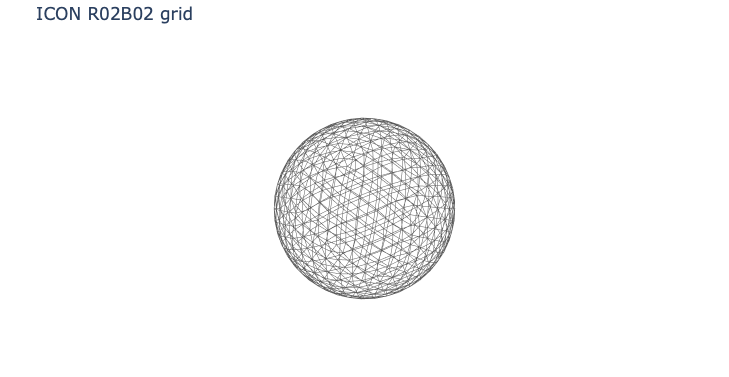

In [5]:
plot_field(grid, None, title=f"ICON {config['grid']} grid", projection="sphere")

## Step 3: Initial Condition

`create_state(grid, config)` creates an empty state container. `init_state(grid, state, "JW26", config)` then prepares the static grid support fields needed by the analytical initializer and fills the state with the Jablonowski-Williamson dry atmosphere.

This initialization can take time on the first run because GT4Py may compile setup kernels. Re-running with a persistent cache should be faster.

The state object keeps the prognostic variables of ICON in memory and exposes diagnostic xarray views for plotting. `state["xarray"]` is the current state. If you want to keep selected output states, copy them explicitly into a list.

The default `projection="flat"` uses longitude and latitude axes. `projection="sphere"` draws the same ICON triangles on a rotatable sphere. The flat plot uses longitude and latitude as Cartesian axes; near the poles this projection is singular, so small white polar gaps are a plotting artifact, not missing grid cells.

In [6]:
state = create_state(grid, config, tracers=None)
print("state fields:", [k for k in ["rho", "theta_v", "exner", "vn", "w"] if state[k] is not None])

[state] creating empty state for R02B02 with tracers=[]
state fields: []


In [ ]:
init_state(grid, state, "JW26", config)
print("current xarray sizes:", dict(state["xarray"].sizes))

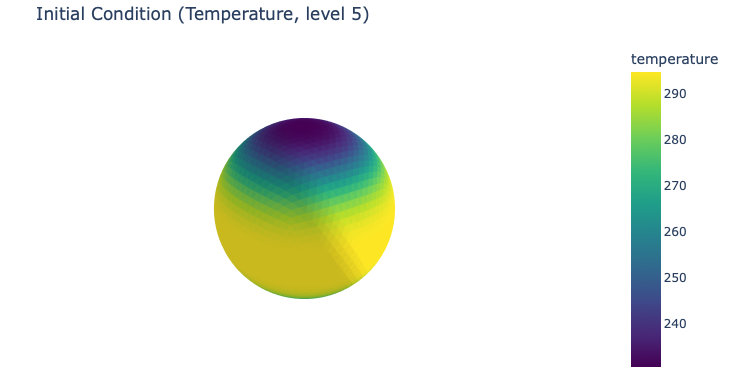

In [7]:
plot_field(
    grid,
    state["temperature"],
    title=f"Initial Condition (Temperature, level {plot_level})",
    colorbar_label="K",
    level=plot_level,
    projection="sphere",
)

## Step 4: Integrate

`create_model(grid, state, config)` is where the actual ICON model components and time-step state are initialized. GT4Py compilation is lazy, so creating the model and the first call to `model.step(...)` may still compile components before actually doing time-stepping.

`count` is the number of timesteps to integrate forward in time from the current state. Here we compute how many timesteps make one day, then call `model.step(...)` once per simulated day. After each day, we copy the current xarray state into `daily_states`, which lets later plots show anomalies such as `daily_states[n]["temperature"] - daily_states[0]["temperature"]`.

Diagnostics are a separate list and are only collected because we pass `diagnostics=diagnostics` into `model.step(...)`. One diagnostic entry is appended after each `model.step(...)` call.

In [8]:
model = create_model(grid, state, config)

diagnostics = []
daily_states = [state["xarray"].copy(deep=True)]
timesteps_per_day = round(24 * 60 * 60 / config["dtime_seconds"])
days_to_run = 8

for day in range(1, days_to_run + 1):
    model.step(grid, state, count=timesteps_per_day, diagnostics=diagnostics)
    daily_states.append(state["xarray"].copy(deep=True))

print("captured daily states:", len(daily_states))
print("recorded diagnostic timesteps:", len(diagnostics))

[model] initializing ICON4Py dycore/diffusion
[model] ready
[step] R02B03: +720 timesteps, step_count=720, time=2000-01-02T00:00:00
[step] R02B03: +720 timesteps, step_count=1440, time=2000-01-03T00:00:00
[step] R02B03: +720 timesteps, step_count=2160, time=2000-01-04T00:00:00
[step] R02B03: +720 timesteps, step_count=2880, time=2000-01-05T00:00:00
[step] R02B03: +720 timesteps, step_count=3600, time=2000-01-06T00:00:00
[step] R02B03: +720 timesteps, step_count=4320, time=2000-01-07T00:00:00
[step] R02B03: +720 timesteps, step_count=5040, time=2000-01-08T00:00:00
[step] R02B03: +720 timesteps, step_count=5760, time=2000-01-09T00:00:00
captured daily states: 9
recorded diagnostic timesteps: 8


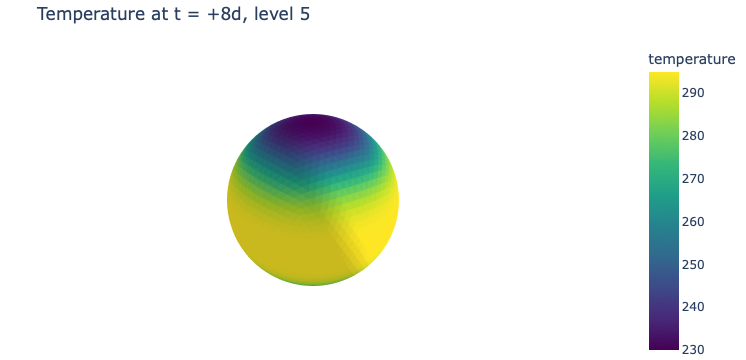

In [9]:
plot_field(
    grid,
    daily_states[-1]["temperature"],
    title=f"Temperature at t = +{days_to_run}d, level {plot_level}",
    colorbar_label="K",
    level=plot_level,
    projection="sphere",
)

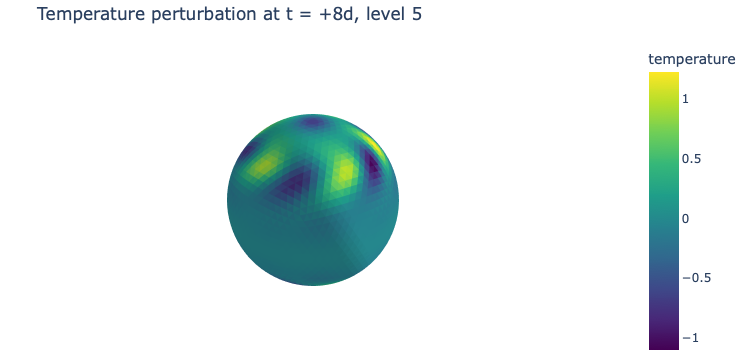

In [10]:
plot_field(
    grid,
    daily_states[-1]["temperature"] - daily_states[0]["temperature"],
    title=f"Temperature perturbation at t = +{days_to_run}d, level {plot_level}",
    colorbar_label="K",
    level=plot_level,
    projection="sphere",
)

array([<Axes: title={'center': 'temperature diagnostics'}, xlabel='timestep', ylabel='temperature'>,
       <Axes: title={'center': 'rho diagnostics'}, xlabel='timestep', ylabel='rho'>,
       <Axes: title={'center': 'exner diagnostics'}, xlabel='timestep', ylabel='exner'>],
      dtype=object)

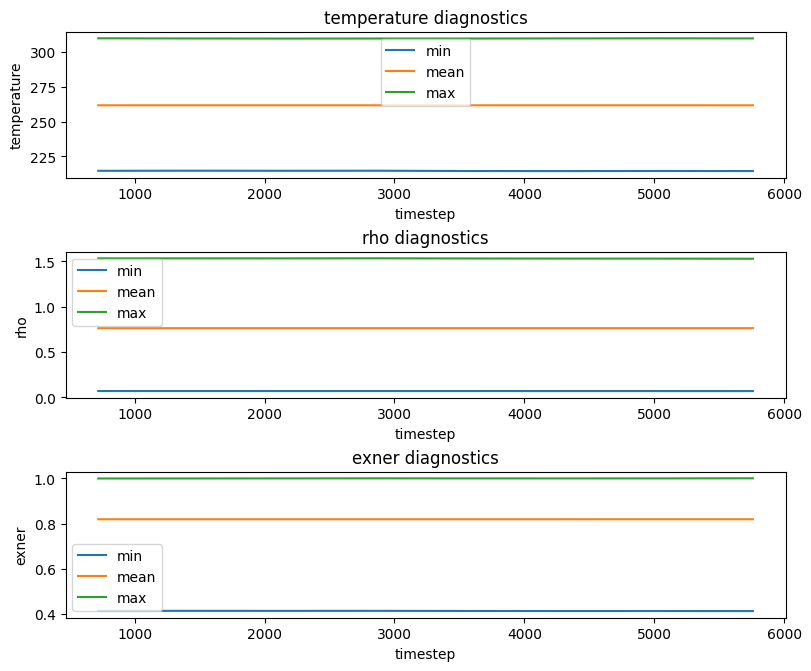

In [11]:
plot_diagnostics(diagnostics, fields=["temperature", "rho", "exner"])